# Fractal Pareidolia + DAT Priming — Results Analysis

**Model:** Gemma 4 26B (google/gemma-4-26b-a4b-it) via OpenRouter  
**Images:** 161 fractal images (FD 1.35 + FD 1.7)  
**Design:** 3 temperatures × 10 runs per image  
**Protocol:** Fractal percept prompt → DAT prompt (same thread)


In [1]:
import json
from pathlib import Path
from collections import defaultdict

# =============================================================================
# CONFIGURATION
# =============================================================================
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

# Paths
ROOT = Path("../../new-FD-images")
IMAGE_DIRS = [ROOT / "FD135", ROOT / "FD17"]
MAIN_OUTPUT = Path("main_results.jsonl")


def get_all_images():
    """Returns a list of all image Path objects."""
    images = []
    for d in IMAGE_DIRS:
        if d.exists():
            images.extend(d.glob("*.png"))
            images.extend(d.glob("*.jpg"))
    return images


def main():
    print("Analyzing missing data in detail...\n")
    images = get_all_images()

    if not images:
        print("! No images found! Check your folder paths.")
        return

    # 1. Generate all EXPECTED combinations
    # Tuple format: (temperature, filename, run_id)
    expected_main = set()
    image_to_folder = {}

    for img in images:
        image_to_folder[img.name] = img.parent.name
        for temp in TEMPERATURES:
            for run_id in range(1, NUM_RUNS + 1):
                expected_main.add((temp, img.name, run_id))

    # 2. Read COMPLETED combinations from file
    completed_main = set()
    if MAIN_OUTPUT.exists():
        with open(MAIN_OUTPUT, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    record = json.loads(line)
                    completed_main.add((record["temperature"], record["file"], record["run_id"]))
                except json.JSONDecodeError:
                    pass

    # 3. Find MISSING combinations (Expected - Completed)
    missing_main = expected_main - completed_main

    print("-" * 50)
    print(f"Total Images Found:    {len(images)}")
    print(f"Total Expected Runs:   {len(expected_main)}")
    print(f"Total Completed Runs:  {len(completed_main)}")
    print(f"Total Missing Runs:    {len(missing_main)}")
    print("-" * 50)

    if len(missing_main) == 0:
        print("All main experiment tests are 100% completed!")
        return

    print("\n>>> DETAILED LIST OF MISSING TESTS <<<\n")

    # Group the missing data by image for readable output
    missing_by_image = defaultdict(lambda: defaultdict(list))
    for temp, img_name, run_id in missing_main:
        missing_by_image[img_name][temp].append(run_id)

    # Print the grouped missing data
    for img_name, temp_dict in missing_by_image.items():
        folder = image_to_folder.get(img_name, "Unknown")
        print(f"[Image]: {img_name}  |  [Folder]: {folder}")

        for temp in sorted(temp_dict.keys()):
            runs = sorted(temp_dict[temp])
            print(f"    - Temp {temp}: Missing Runs -> {runs}")
        print("-" * 40)


if __name__ == "__main__":
    main()

Analyzing missing data in detail...

--------------------------------------------------
Total Images Found:    161
Total Expected Runs:   4830
Total Completed Runs:  4612
Total Missing Runs:    218
--------------------------------------------------

>>> DETAILED LIST OF MISSING TESTS <<<

[Image]: FD_1.7_14.png  |  [Folder]: FD17
    - Temp 1.0: Missing Runs -> [1, 2, 3]
----------------------------------------
[Image]: FD_1.7_13.png  |  [Folder]: FD17
    - Temp 1.0: Missing Runs -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
----------------------------------------
[Image]: FD_1.35_76.png  |  [Folder]: FD135
    - Temp 1.0: Missing Runs -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    - Temp 1.5: Missing Runs -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
----------------------------------------
[Image]: FD_1.35_77.png  |  [Folder]: FD135
    - Temp 1.0: Missing Runs -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    - Temp 1.5: Missing Runs -> [1, 2, 3, 4, 5, 6, 7, 8]
----------------------------------------
[Image]: FD_1.35_74

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
BLUE   = '#378ADD'
GRAY   = '#888780'
PINK   = '#D4537E'

# ── Load data ──
baseline = [json.loads(l) for l in open('dat_baseline_results.jsonl')]
main     = [json.loads(l) for l in open('main_results.jsonl')]

print(f"Baseline: {len(baseline)} records")
print(f"Main:     {len(main)} records")
print(f"Total:    {len(baseline) + len(main)} records")


Baseline: 30 records
Main:     4612 records
Total:    4642 records


## 1. Data preparation

In [2]:
# ── Flatten main results into a DataFrame ──
rows = []
for r in main:
    fp = r.get('fractal_parsed') or {}
    dp = r.get('dat_parsed') or {}
    percepts = fp.get('percepts', [])
    words    = dp.get('words', [])

    rows.append({
        'temperature':  r['temperature'],
        'temp_label':   r['temp_label'],
        'file':         r['file'],
        'fd':           r['fd'],
        'run_id':       r['run_id'],
        'n_percepts':   len(percepts),
        'percept_labels': [p.get('label','').lower() for p in percepts],
        'confidences':  [p.get('confidence_present', 0) for p in percepts],
        'dat_words':    [w.lower() for w in words],
        'n_dat_words':  len(words),
        'ms_fractal':   r['ms_fractal'],
        'ms_dat':       r['ms_dat'],
    })

df = pd.DataFrame(rows)

# Baseline DataFrame
b_rows = []
for r in baseline:
    dp = r.get('dat_parsed') or {}
    words = dp.get('words', [])
    b_rows.append({
        'temperature': r['temperature'],
        'temp_label':  r['temp_label'],
        'run_id':      r['run_id'],
        'dat_words':   [w.lower() for w in words],
        'ms':          r['ms'],
    })

df_b = pd.DataFrame(b_rows)

print(f"Main DataFrame: {df.shape}")
print(f"Baseline DataFrame: {df_b.shape}")
print()
print(df.groupby(['fd','temperature'])['n_percepts'].describe().round(2))


Main DataFrame: (4612, 12)
Baseline DataFrame: (30, 5)

                   count  mean   std  min  25%  50%  75%  max
fd    temperature                                            
FD135 0.0          810.0  3.55  0.60  1.0  3.0  4.0  4.0  8.0
      1.0          687.0  3.57  0.55  3.0  3.0  4.0  4.0  5.0
      1.5          778.0  3.62  0.58  2.0  3.0  4.0  4.0  5.0
FD17  0.0          800.0  3.90  0.55  3.0  4.0  4.0  4.0  5.0
      1.0          737.0  3.96  0.53  3.0  4.0  4.0  4.0  5.0
      1.5          800.0  3.96  0.56  3.0  4.0  4.0  4.0  5.0


## 2. Percept count by fractal dimension × temperature

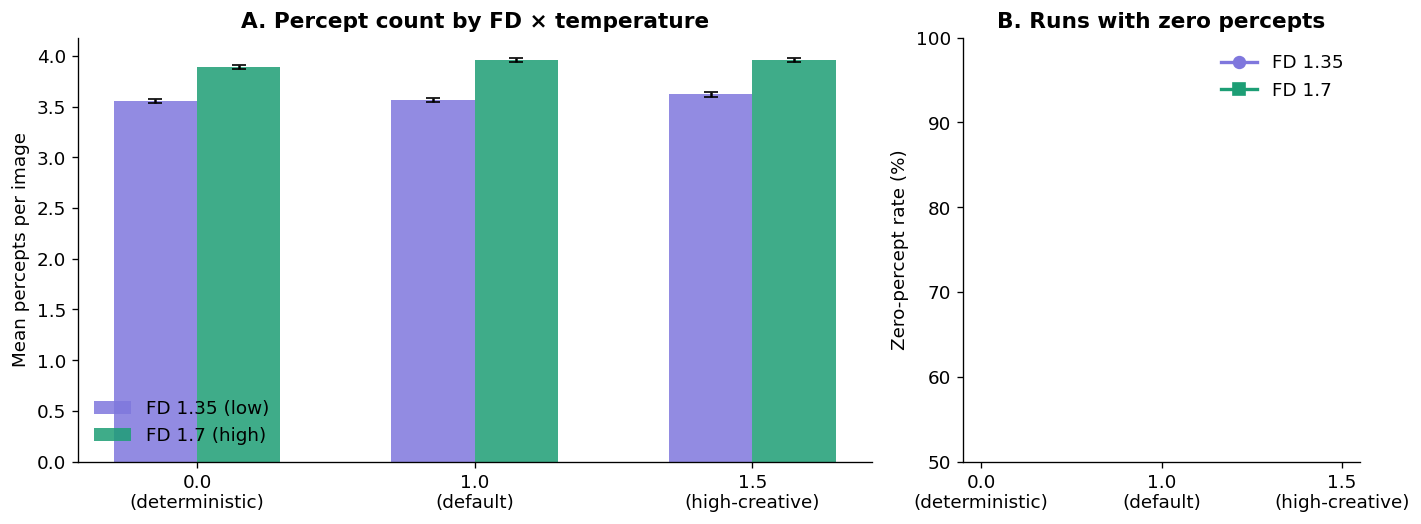


FD 1.35 vs FD 1.7 (image-level means):
  FD 1.35: 3.563 ± 0.390  (n=81)
  FD 1.7:  3.942 ± 0.353  (n=80)
  t = -6.456, p = 0.0000


<Figure size 768x576 with 0 Axes>

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [2, 1]})

# ── Panel A: Grouped bar chart ──
ax = axes[0]
temps = [0.0, 1.0, 1.5]
temp_names = ['0.0\n(deterministic)', '1.0\n(default)', '1.5\n(high-creative)']
x = np.arange(len(temps))
w = 0.3

means_135 = [df[(df.fd=='FD135') & (df.temperature==t)]['n_percepts'].mean() for t in temps]
means_17  = [df[(df.fd=='FD17')  & (df.temperature==t)]['n_percepts'].mean() for t in temps]
sems_135  = [df[(df.fd=='FD135') & (df.temperature==t)]['n_percepts'].sem()  for t in temps]
sems_17   = [df[(df.fd=='FD17')  & (df.temperature==t)]['n_percepts'].sem()  for t in temps]

ax.bar(x - w/2, means_135, w, yerr=sems_135, label='FD 1.35 (low)', color=PURPLE, alpha=0.85, capsize=4)
ax.bar(x + w/2, means_17,  w, yerr=sems_17,  label='FD 1.7 (high)', color=TEAL,   alpha=0.85, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(temp_names)
ax.set_ylabel('Mean percepts per image')
ax.set_title('A. Percept count by FD × temperature')
ax.legend(frameon=False)

# ── Panel B: Zero-percept rate ──
ax = axes[1]
zero_135 = [100 * (df[(df.fd=='FD135') & (df.temperature==t)]['n_percepts'] == 0).mean() for t in temps]
zero_17  = [100 * (df[(df.fd=='FD17')  & (df.temperature==t)]['n_percepts'] == 0).mean() for t in temps]

ax.plot(temp_names, zero_135, 'o-', color=PURPLE, label='FD 1.35', linewidth=2, markersize=7)
ax.plot(temp_names, zero_17,  's-', color=TEAL,   label='FD 1.7',  linewidth=2, markersize=7)
ax.set_ylabel('Zero-percept rate (%)')
ax.set_title('B. Runs with zero percepts')
ax.legend(frameon=False)
ax.set_ylim(50, 100)

plt.tight_layout()
plt.savefig('fig1_percepts_by_fd_temp.png', dpi=150, bbox_inches='tight')
plt.show()

# ── t-test ──
img_means = df.groupby(['fd','file'])['n_percepts'].mean().reset_index()
fd135_vals = img_means[img_means.fd=='FD135']['n_percepts']
fd17_vals  = img_means[img_means.fd=='FD17']['n_percepts']
t_stat, p_val = stats.ttest_ind(fd135_vals, fd17_vals)
print(f"\nFD 1.35 vs FD 1.7 (image-level means):")
print(f"  FD 1.35: {fd135_vals.mean():.3f} ± {fd135_vals.std():.3f}  (n={len(fd135_vals)})")
print(f"  FD 1.7:  {fd17_vals.mean():.3f} ± {fd17_vals.std():.3f}  (n={len(fd17_vals)})")
print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")
plt.savefig('/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/new-FD-images/results/Gemma3-26b/fig1_percepts_by_fd_temp.png', dpi=300, bbox_inches='tight')


## 3. What does the model see? — Top percept labels

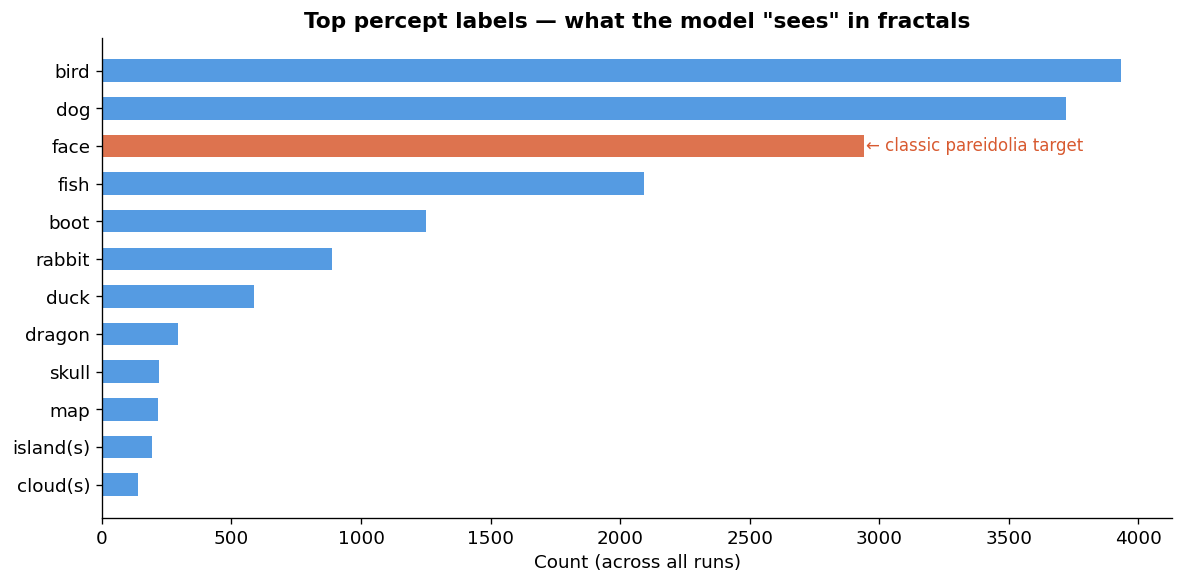

In [4]:
# Merge singular/plural
all_labels = []
for labels in df['percept_labels']:
    all_labels.extend(labels)

# Simple plural merge
merged = Counter()
for label, count in Counter(all_labels).items():
    key = label.rstrip('s') if label.endswith('s') and label[:-1] in Counter(all_labels) else label
    # manual merges
    if key in ('cloud', 'clouds'): key = 'cloud(s)'
    elif key in ('island', 'islands'): key = 'island(s)'
    elif key in ('blob', 'blobs'): key = 'blob(s)'
    elif key in ('continent', 'continents'): key = 'continent(s)'
    elif key in ('ink', 'inkblot'): key = 'ink/inkblot'
    merged[key] += count

top = merged.most_common(12)
labels_sorted = [l for l, c in reversed(top)]
counts_sorted = [c for l, c in reversed(top)]

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CORAL if l == 'face' else BLUE for l in labels_sorted]
bars = ax.barh(labels_sorted, counts_sorted, color=colors, alpha=0.85, height=0.6)
ax.set_xlabel('Count (across all runs)')
ax.set_title('Top percept labels — what the model "sees" in fractals')

# Annotate face bar
for bar, label in zip(bars, labels_sorted):
    if label == 'face':
        ax.annotate('← classic pareidolia target',
                    xy=(bar.get_width() + 10, bar.get_y() + bar.get_height()/2),
                    fontsize=10, color=CORAL, va='center')

plt.tight_layout()
plt.savefig('fig2_top_percepts.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Percept label distribution by fractal dimension

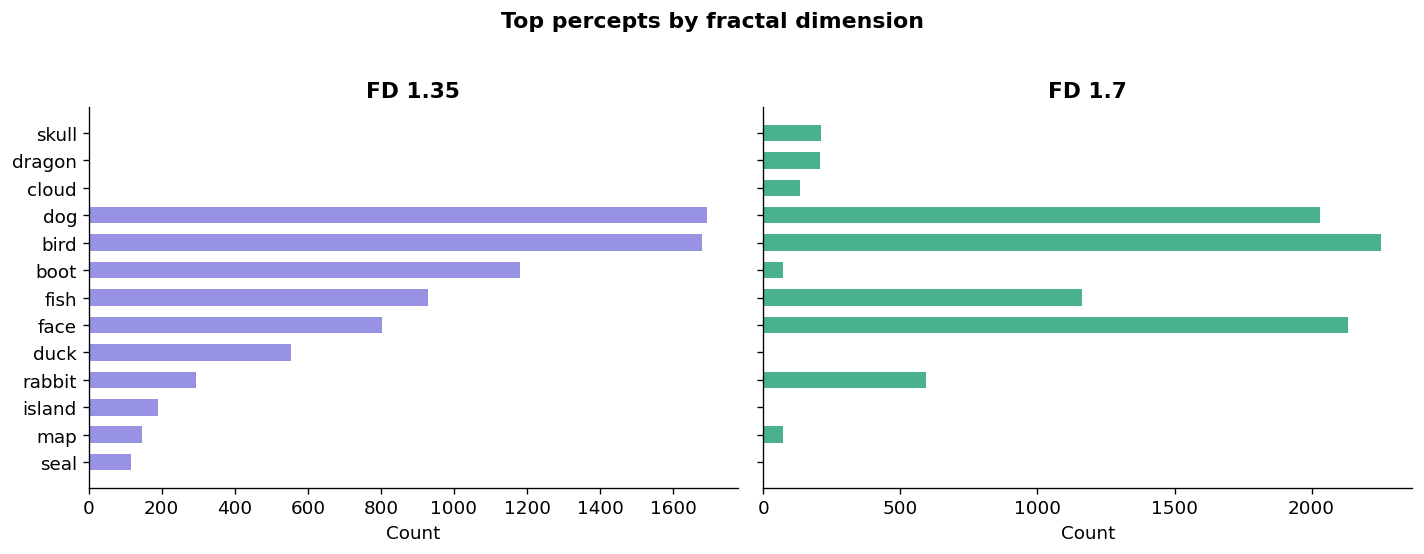

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, fd, color, title in zip(axes, ['FD135', 'FD17'], [PURPLE, TEAL], ['FD 1.35', 'FD 1.7']):
    sub = df[df.fd == fd]
    labels_flat = [l for ls in sub['percept_labels'] for l in ls]
    top = Counter(labels_flat).most_common(10)
    ax.barh([l for l, c in reversed(top)], [c for l, c in reversed(top)],
            color=color, alpha=0.8, height=0.6)
    ax.set_title(title)
    ax.set_xlabel('Count')

plt.suptitle('Top percepts by fractal dimension', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_percepts_by_fd.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Confidence distribution

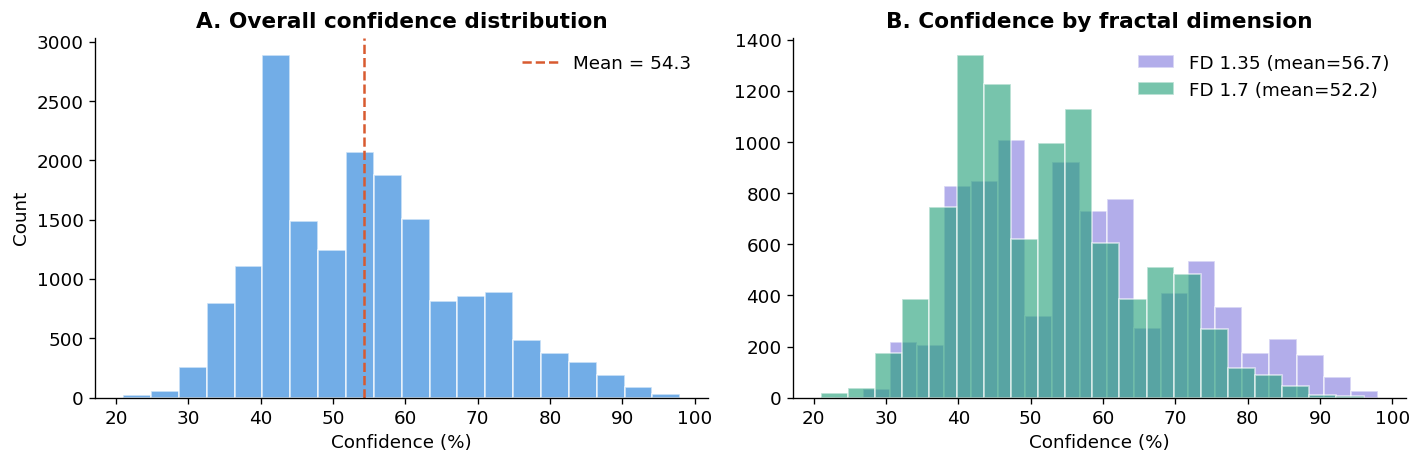

Overall: n=17352, mean=54.3, median=54.0


In [6]:
all_conf = [c for cs in df['confidences'] for c in cs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall histogram
ax = axes[0]
ax.hist(all_conf, bins=20, color=BLUE, alpha=0.7, edgecolor='white')
ax.axvline(np.mean(all_conf), color=CORAL, linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(all_conf):.1f}')
ax.set_xlabel('Confidence (%)')
ax.set_ylabel('Count')
ax.set_title('A. Overall confidence distribution')
ax.legend(frameon=False)

# By FD
ax = axes[1]
conf_135 = [c for _, row in df[df.fd=='FD135'].iterrows() for c in row['confidences']]
conf_17  = [c for _, row in df[df.fd=='FD17'].iterrows()  for c in row['confidences']]

ax.hist(conf_135, bins=20, alpha=0.6, color=PURPLE, label=f'FD 1.35 (mean={np.mean(conf_135):.1f})', edgecolor='white')
ax.hist(conf_17,  bins=20, alpha=0.6, color=TEAL,   label=f'FD 1.7 (mean={np.mean(conf_17):.1f})',  edgecolor='white')
ax.set_xlabel('Confidence (%)')
ax.set_title('B. Confidence by fractal dimension')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('fig4_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Overall: n={len(all_conf)}, mean={np.mean(all_conf):.1f}, median={np.median(all_conf):.1f}")


## 6. DAT baseline — vocabulary diversity by temperature

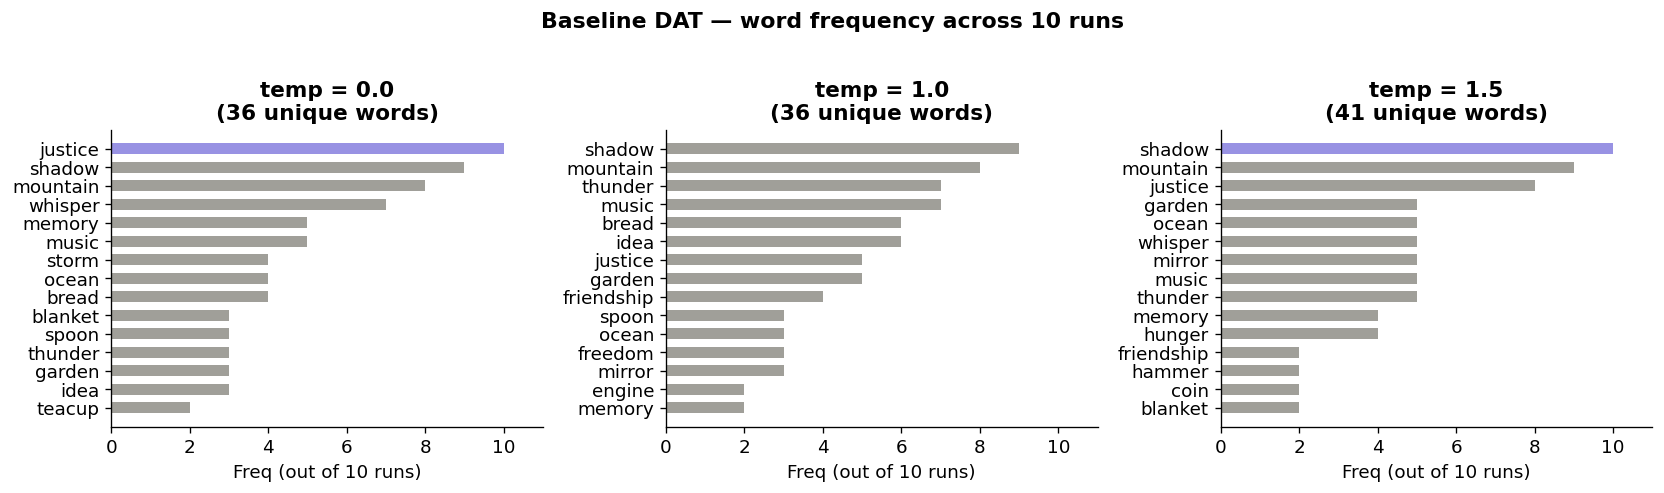

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, temp in zip(axes, [0.0, 1.0, 1.5]):
    sub = df_b[df_b.temperature == temp]
    all_w = [w for ws in sub['dat_words'] for w in ws]
    wc = Counter(all_w).most_common(15)

    colors_bar = [PURPLE if c == 10 else GRAY for _, c in reversed(wc)]
    ax.barh([w for w, c in reversed(wc)], [c for w, c in reversed(wc)],
            color=colors_bar, alpha=0.8, height=0.6)
    ax.set_title(f'temp = {temp}\n({len(set(all_w))} unique words)')
    ax.set_xlabel('Freq (out of 10 runs)')
    ax.set_xlim(0, 11)

plt.suptitle('Baseline DAT — word frequency across 10 runs', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_baseline_dat.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Priming effect — fractal exposure expands DAT vocabulary

The key comparison: how many unique words does the model produce in DAT baseline vs after seeing a fractal?


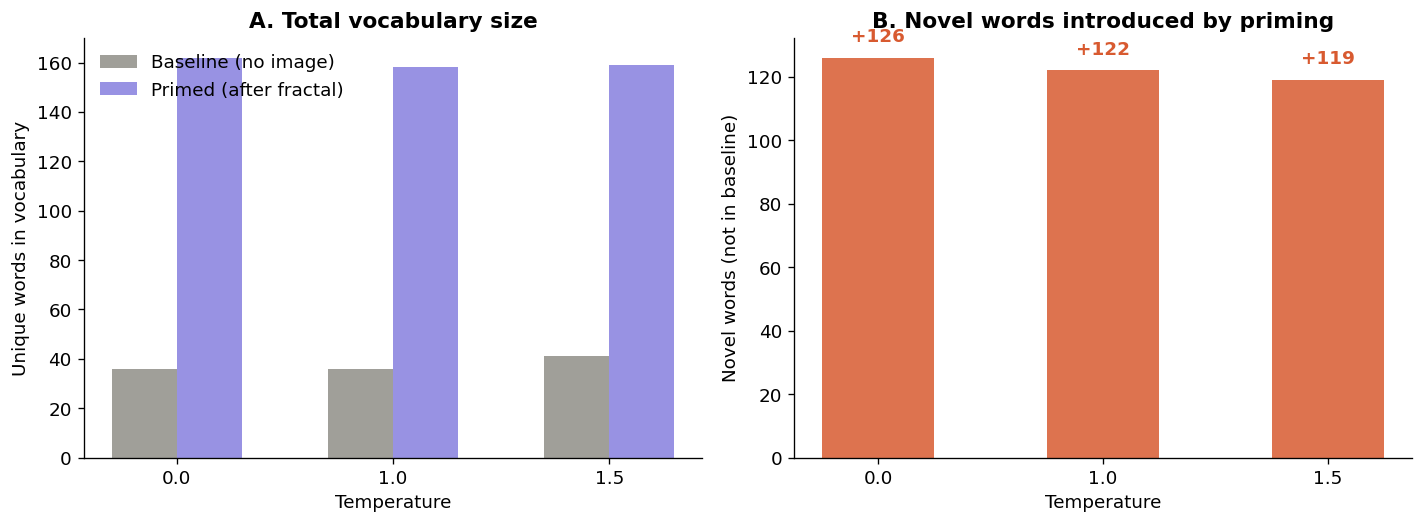

Novel words at temp=0.0 (fractal broke determinism):
  ['anger', 'apology', 'apple', 'baby', 'banana', 'basket', 'bicycle', 'bird', 'book', 'brick', 'bridge', 'bucket', 'butterfly', 'button', 'cabbage', 'cactus', 'calendar', 'candle', 'carpet', 'castle', 'cat', 'chair', 'child', 'childhood', 'city', 'clock', 'cloud', 'coin', 'courage', 'diamond', 'dog', 'dragon', 'dust', 'engine', 'factory', 'family', 'finger', 'fire', 'flame', 'forest', 'freedom', 'friend', 'funeral', 'fungus', 'game', 'garbage', 'garlic', 'glass', 'grief', 'happiness', 'hurricane', 'infant', 'insect', 'island', 'jacket', 'jealousy', 'jellyfish', 'joy', 'jungle', 'key', 'kitchen', 'ladder', 'language', 'lantern', 'laugh', 'library', 'market', 'meadow', 'melody', 'melon', 'mirror', 'money', 'moonlight', 'mosquito', 'moss', 'museum', 'passport', 'pencil', 'penny', 'pepper', 'piano', 'pigeon', 'planet', 'pocket', 'poverty', 'prison', 'puddle', 'pumpkin', 'puzzle', 'rabbit', 'rain', 'rainbow', 'rock', 'rocket', 'rope', 's

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Panel A: Vocabulary size ──
ax = axes[0]
temps = [0.0, 1.0, 1.5]
temp_names = ['0.0', '1.0', '1.5']

baseline_vocab = []
primed_vocab   = []
novel_counts   = []

for t in temps:
    b_words = set(w for _, row in df_b[df_b.temperature==t].iterrows() for w in row['dat_words'])
    p_words = set(w for _, row in df[df.temperature==t].iterrows() for w in row['dat_words'])
    baseline_vocab.append(len(b_words))
    primed_vocab.append(len(p_words))
    novel_counts.append(len(p_words - b_words))

x = np.arange(len(temps))
w = 0.3
ax.bar(x - w/2, baseline_vocab, w, color=GRAY,   alpha=0.8, label='Baseline (no image)')
ax.bar(x + w/2, primed_vocab,   w, color=PURPLE, alpha=0.8, label='Primed (after fractal)')
ax.set_xticks(x)
ax.set_xticklabels(temp_names)
ax.set_xlabel('Temperature')
ax.set_ylabel('Unique words in vocabulary')
ax.set_title('A. Total vocabulary size')
ax.legend(frameon=False)

# ── Panel B: Novel words ──
ax = axes[1]
ax.bar(temp_names, novel_counts, color=CORAL, alpha=0.85, width=0.5)
ax.set_xlabel('Temperature')
ax.set_ylabel('Novel words (not in baseline)')
ax.set_title('B. Novel words introduced by priming')

for i, v in enumerate(novel_counts):
    ax.text(i, v + 5, f'+{v}', ha='center', fontweight='bold', fontsize=11, color=CORAL)

plt.tight_layout()
plt.savefig('fig6_priming_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("Novel words at temp=0.0 (fractal broke determinism):")
b_words_0 = set(w for _, row in df_b[df_b.temperature==0.0].iterrows() for w in row['dat_words'])
p_words_0 = set(w for _, row in df[df.temperature==0.0].iterrows() for w in row['dat_words'])
novel_0 = sorted(p_words_0 - b_words_0)
print(f"  {novel_0}")


## 8. Most pareidolic images — per-image percept count

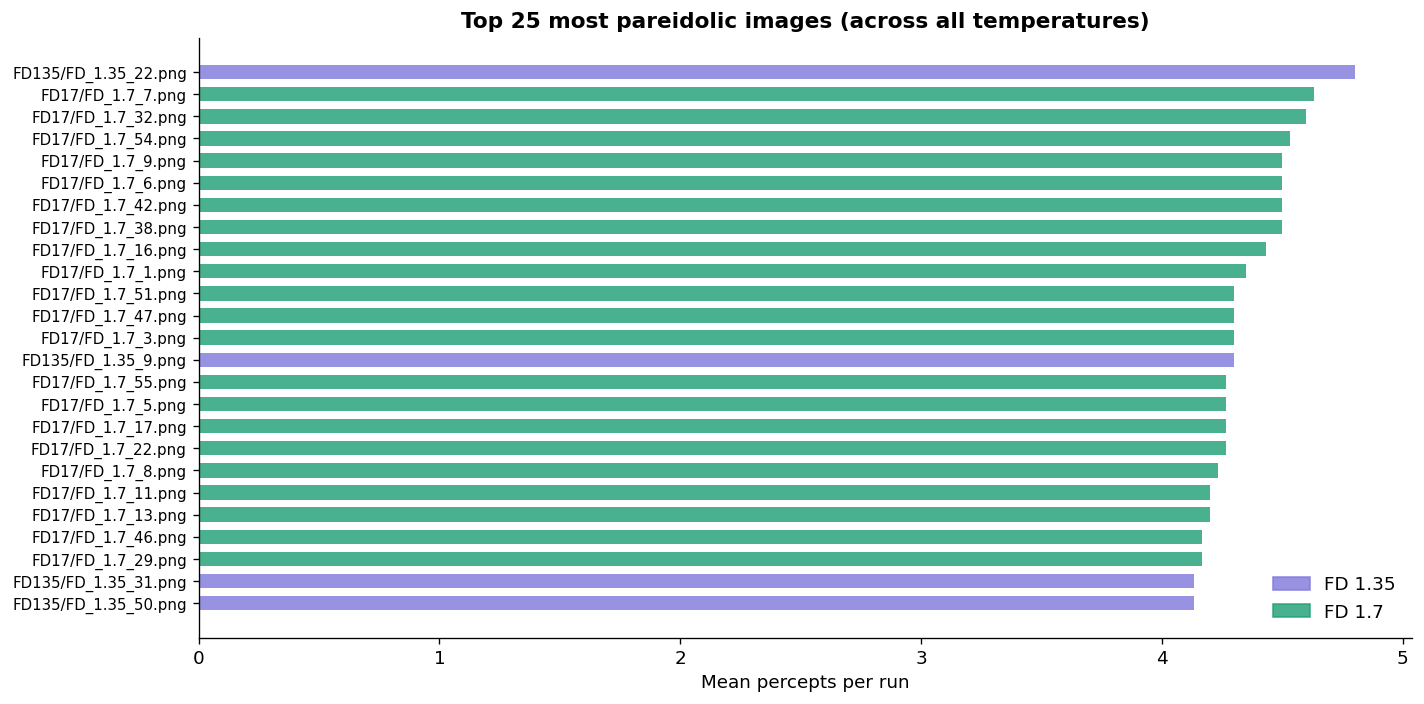


FD distribution in top 25:
fd
FD17     21
FD135     4
Name: count, dtype: int64


In [9]:
# Mean percepts per image across all temps and runs
img_stats = df.groupby(['fd', 'file']).agg(
    mean_percepts=('n_percepts', 'mean'),
    std_percepts=('n_percepts', 'std'),
    max_percepts=('n_percepts', 'max'),
    zero_rate=('n_percepts', lambda x: (x == 0).mean() * 100)
).reset_index().sort_values('mean_percepts', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_n = 25
top_imgs = img_stats.head(top_n)

colors = [PURPLE if fd == 'FD135' else TEAL for fd in top_imgs['fd']]
bars = ax.barh(range(top_n), top_imgs['mean_percepts'].values, color=colors, alpha=0.8, height=0.65)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{row.fd}/{row.file}" for _, row in top_imgs.iterrows()], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean percepts per run')
ax.set_title(f'Top {top_n} most pareidolic images (across all temperatures)')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PURPLE, alpha=0.8, label='FD 1.35'),
                   Patch(color=TEAL,   alpha=0.8, label='FD 1.7')],
          frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('fig7_top_images.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFD distribution in top {top_n}:")
print(top_imgs['fd'].value_counts())


## 9. Latency analysis

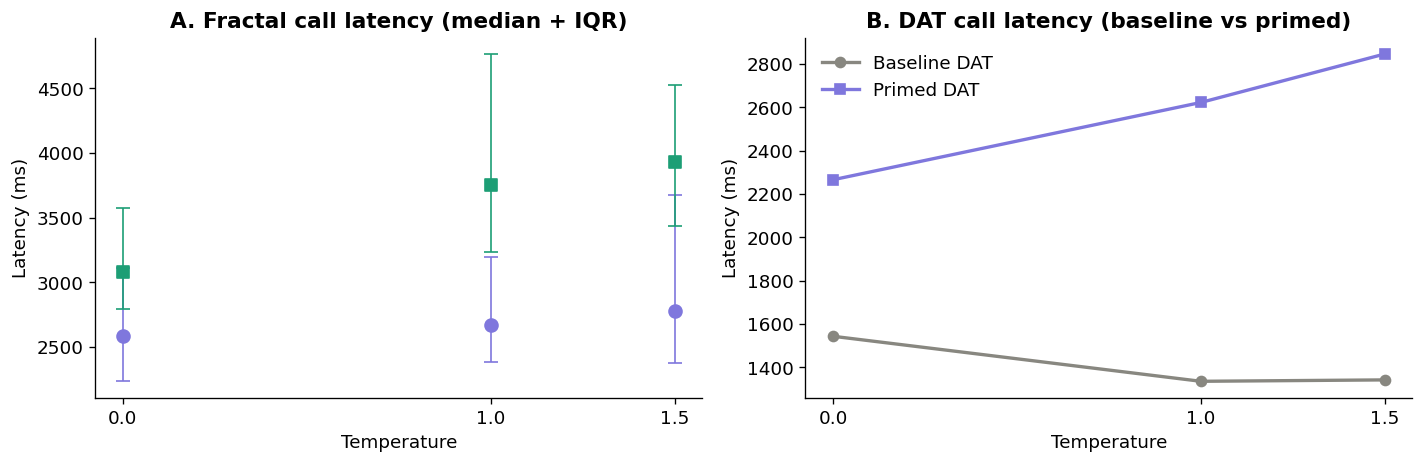

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fractal latency
ax = axes[0]
for fd, color in [('FD135', PURPLE), ('FD17', TEAL)]:
    for temp in [0.0, 1.0, 1.5]:
        sub = df[(df.fd==fd) & (df.temperature==temp)]
        ax.scatter(temp, sub['ms_fractal'].median(), color=color, s=60, zorder=5,
                   marker='o' if fd=='FD135' else 's')
        ax.errorbar(temp, sub['ms_fractal'].median(),
                    yerr=[[sub['ms_fractal'].median() - sub['ms_fractal'].quantile(0.25)],
                          [sub['ms_fractal'].quantile(0.75) - sub['ms_fractal'].median()]],
                    color=color, capsize=4, linewidth=1)
ax.set_xlabel('Temperature')
ax.set_ylabel('Latency (ms)')
ax.set_title('A. Fractal call latency (median + IQR)')
ax.set_xticks([0.0, 1.0, 1.5])

# DAT latency
ax = axes[1]
baseline_lat = [df_b[df_b.temperature==t]['ms'].median() for t in [0.0, 1.0, 1.5]]
primed_lat   = [df[df.temperature==t]['ms_dat'].median() for t in [0.0, 1.0, 1.5]]

ax.plot([0.0, 1.0, 1.5], baseline_lat, 'o-', color=GRAY,   label='Baseline DAT', linewidth=2)
ax.plot([0.0, 1.0, 1.5], primed_lat,   's-', color=PURPLE, label='Primed DAT',   linewidth=2)
ax.set_xlabel('Temperature')
ax.set_ylabel('Latency (ms)')
ax.set_title('B. DAT call latency (baseline vs primed)')
ax.legend(frameon=False)
ax.set_xticks([0.0, 1.0, 1.5])

plt.tight_layout()
plt.savefig('fig8_latency.png', dpi=150, bbox_inches='tight')
plt.show()
